# Project 1 – Exercise 1: Enzyme Kinetics (Michaelis-Menten)
**Batch reactor design and operation**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

## Part (a) – Mass Balances

The elementary reactions are:
$$S + E \xrightarrow{k_f} ES, \quad ES \xrightarrow{k_b} S + E, \quad ES \xrightarrow{k_{cat}} P + E$$

Mass balances (in a constant-volume batch reactor, so moles ↔ concentrations):

$$\frac{d[S]}{dt} = -k_f[S][E] + k_b[ES]$$
$$\frac{d[E]}{dt} = -k_f[S][E] + k_b[ES] + k_{cat}[ES]$$
$$\frac{d[ES]}{dt} = k_f[S][E] - k_b[ES] - k_{cat}[ES]$$
$$\frac{d[P]}{dt} = k_{cat}[ES]$$

Note the conservation: $[E] + [ES] = [E_0]$ (total enzyme is conserved).

## Part (b) – Full ODE System

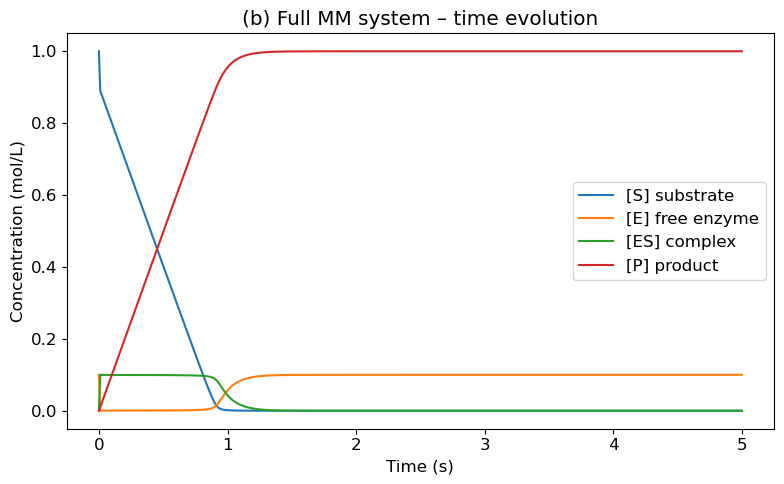

In [3]:
# ─── Parameters ───────────────────────────────────────────────────────────────
kf   = 1e4   # L/(mol·s)
kb  = 20.0   # 1/s  (k_b)
kcat = 10.0   # 1/s

# Initial concentrations  [mol/L]
S0  = 1.0
E0  = 0.1
P0  = 0.0
ES0 = 0.0

t_span = (0, 5)       # seconds
t_eval = np.linspace(0, 5, 500)

# ─── ODE system ───────────────────────────────────────────────────────────────
def ode_full(t, y, kf, kb, kcat):
    S, E, ES, P = y
    dS  = -kf*S*E + kb*ES
    dE  = -kf*S*E + kb*ES + kcat*ES
    dES =  kf*S*E - kb*ES - kcat*ES
    dP  =  kcat*ES
    return [dS, dE, dES, dP]

y0_full = [S0, E0, ES0, P0]
sol_full = solve_ivp(ode_full, t_span, y0_full, args=(kf, kb, kcat),
                     t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-10)

S_f, E_f, ES_f, P_f = sol_full.y

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(sol_full.t, S_f,  label='[S] substrate')
ax.plot(sol_full.t, E_f,  label='[E] free enzyme')
ax.plot(sol_full.t, ES_f, label='[ES] complex')
ax.plot(sol_full.t, P_f,  label='[P] product')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Concentration (mol/L)')
ax.set_title('(b) Full MM system – time evolution')
ax.legend()
plt.tight_layout()
plt.savefig('b_full_ode.png', dpi=150)
plt.show()

#### Observations
Under the quasi-steady-state assumption (QSSA), we impose  

$ \frac{d[ES]}{dt} ≈ 0 $

from the very beginning and solve algebraically for the complex concentration:

$ [ES] ≈ \frac{[E]₀ [S]}{K_M + [S]}$

At very short times (t → 0), the substrate concentration is still essentially [S]₀, so the QSSA immediately predicts a relatively large value of [ES], close to its steady-state level. In contrast, the full dynamic model shows that [ES] must build up from zero, since complex formation occurs at a finite rate. This creates a short initial transient during which the complex concentration increases rapidly but is still below its steady-state value. Therefore, near t = 0, the QSSA overestimates [ES] because it neglects the finite time required to establish the balance between formation and consumption of the enzyme–substrate complex.

## Part (c) – Quasi-Steady State Approximation (QSSA)

Setting $d[ES]/dt = 0$:
$$k_1[S][E] = (k_b + k_{cat})[ES]$$

Using enzyme conservation $[E] = [E_0] - [ES]$:
$$k_f[S]([E_0] - [ES]) = (k_b+k_{cat})[ES]$$
$$[ES] = \frac{[E_0][S]}{K_M + [S]}, \quad K_M = \frac{k_b+k_{cat}}{k_f}$$

The Michaelis constant for our parameters:
$$K_M = \frac{20+10}{10} = 0.3 \text{ mmol/L}$$

In [4]:
KM = ((kb + kcat) / kf)  
print(f'K_M = {KM:.3f} mol/L')

K_M = 0.003 mol/L


## Part (d) – QSSA ODE System

Substituting the QSSA expression for $[ES]$ from part (c) into the original mass balances, $[ES]$ is no longer a dynamic variable. The full 4-ODE system reduces to just **two ODEs**:

$$\frac{d[S]}{dt} = -k_{cat} \cdot \frac{[E_0][S]}{K_M + [S]}$$

$$\frac{d[P]}{dt} = +k_{cat} \cdot \frac{[E_0][S]}{K_M + [S]}$$

with $K_M = \dfrac{k_b + k_{cat}}{k_f}$.

Note that $\dfrac{d[S]}{dt} = -\dfrac{d[P]}{dt}$, so mass is conserved: $[S] + [P] = [S_0]$ at all times.  
$[E]$ and $[ES]$ are recovered algebraically at any time point:

$$[ES] = \frac{[E_0][S]}{K_M + [S]}, \qquad [E] = [E_0] - [ES]$$

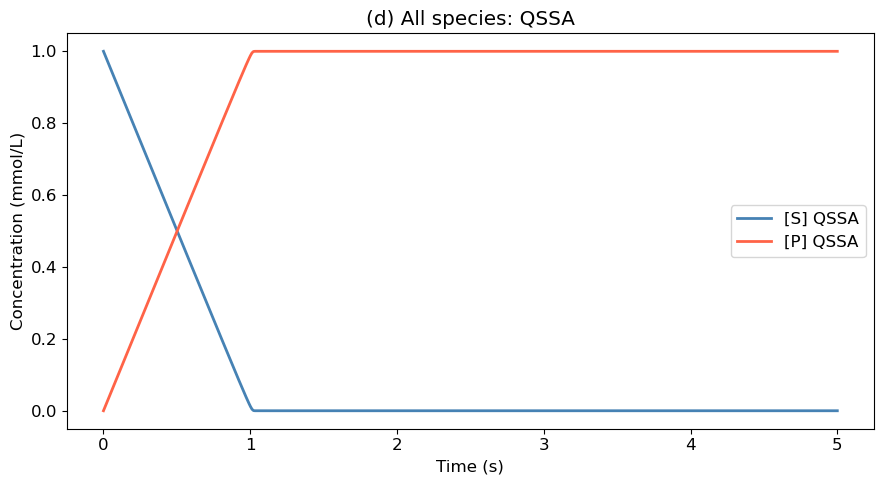

In [5]:
# Under QSSA: [ES] = E0*S / (KM + S)
# Only two ODEs needed: dS/dt and dP/dt

def ode_qssa(t, y, kcat, KM, E0 ):
    S, P = y
    ES = (E0 * S )/ (KM + S)
    dS = -kcat*ES
    dP =  kcat*ES
    return [dS, dP]

y0_qssa = [S0, P0]
sol_qssa = solve_ivp(ode_qssa, t_span, y0_qssa, args=(kcat, KM, E0),
                     t_eval=t_eval, method='BDF', rtol=1e-8, atol=1e-10)

S_q, P_q = sol_qssa.y

# Recover ES algebraically
ES_q = E0 * S_q / (KM + S_q)

# --- Plot all species on a single graph: Full ODE (solid) vs QSSA (dashed) ---+

fig, ax = plt.subplots(figsize=(9, 5))


ax.plot(sol_qssa.t, S_q,  color='steelblue',  lw=2, label='[S] QSSA')


ax.plot(sol_qssa.t, P_q,  color='tomato',     lw=2, label='[P] QSSA')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Concentration (mmol/L)')
ax.set_title('(d) All species: QSSA')
ax.legend()
plt.tight_layout()
plt.savefig('d_qssa_comparison.png', dpi=150)
plt.show()


#fig, ax = plt.subplots(figsize=(9, 5))

#ax.plot(sol_full.t, S_f,  color='steelblue',  lw=2,        label='[S] Full ODE')
#ax.plot(sol_qssa.t, S_q,  color='steelblue',  lw=2, ls='--', label='[S] QSSA')

#ax.plot(sol_full.t, E_f,  color='seagreen',   lw=2,        label='[E] Full ODE')
#ax.plot(sol_qssa.t, E_q,  color='seagreen',   lw=2, ls='--', label='[E] QSSA')

#ax.plot(sol_full.t, ES_f, color='darkorange',  lw=2,        label='[ES] Full ODE')
#ax.plot(sol_qssa.t, ES_q, color='darkorange',  lw=2, ls='--', label='[ES] QSSA')

#ax.plot(sol_full.t, P_f,  color='tomato',     lw=2,        label='[P] Full ODE')
#ax.plot(sol_qssa.t, P_q,  color='tomato',     lw=2, ls='--', label='[P] QSSA')

#ax.set_xlabel('Time (s)')
#ax.set_ylabel('Concentration (mmol/L)')
#ax.set_title('(d) All species: Full ODE (solid) vs QSSA (dashed)')
#ax.legend()
#plt.tight_layout()
#plt.savefig('d_qssa_comparison.png', dpi=150)
#plt.show()
#print('The QSSA slightly overestimates [P] at very early times (before [ES] reaches')
#print('its pseudo-steady state), but converges quickly to the full solution.')

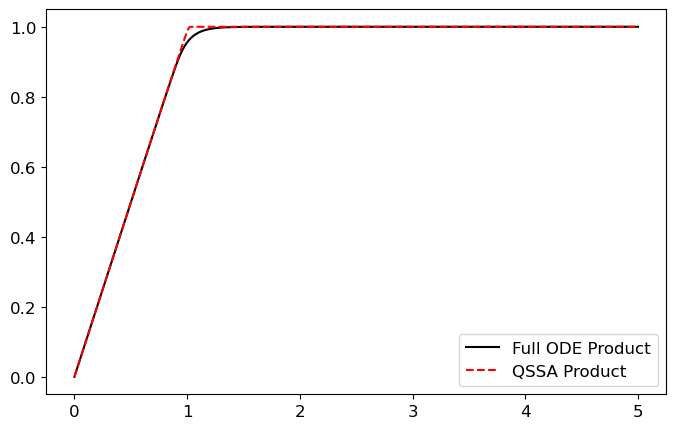

In [6]:
# 1. Run the Full ODE (using the function already defined above)
sol_full = solve_ivp(ode_full, t_span, [S0, E0, 0, 0], args=(kf, kb, kcat),
                     t_eval=t_eval, method='Radau')

# 2. Run the QSSA (using the function already defined above)
# Assuming you already ran the cell with 'def ode_qssa'
sol_qssa = solve_ivp(ode_qssa, t_span, [S0, 0], args=(kcat, KM, E0),
                     t_eval=t_eval, method='BDF')

# 3. Plot Comparison
plt.plot(sol_full.t, sol_full.y[3], 'k-', label='Full ODE Product')
plt.plot(sol_qssa.t, sol_qssa.y[1], 'r--', label='QSSA Product')
plt.legend()
plt.show()

## Part (e) – Initial Rate v(t=0) as a function of parameters

The MM equation: $v = \frac{v_{max}[S]}{K_M + [S]}$ where $v_{max} = k_{cat}[E_0]$.

At $t=0$, $[S] = S_0$:
$$v_0 = \frac{k_{cat}[E_0]S_0}{K_M + S_0}$$

QSSA validity requires $[E_0] \ll [S_0]$, so we scan $[E_0]$ in $[0.0001, 0.1]$ mol/L.

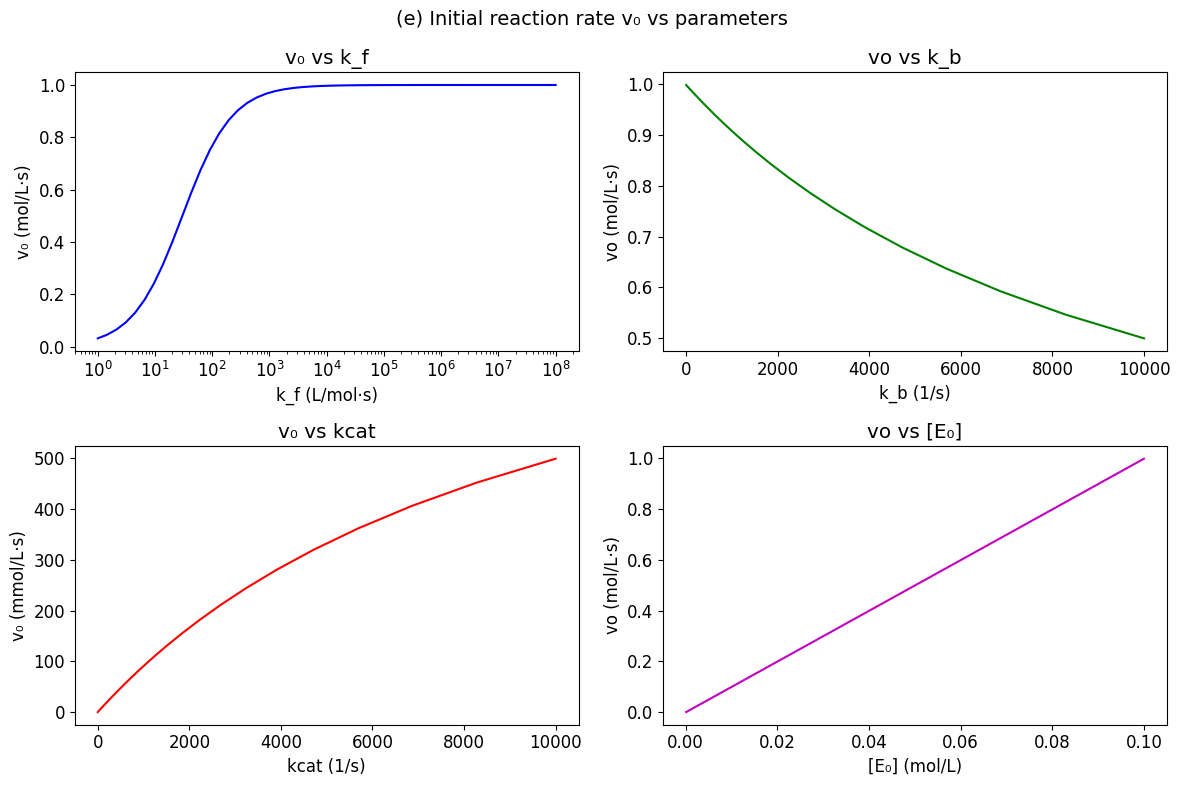

In [5]:
# ─── Ranges ───────────────────────────────────────────────────────────────────
kf_range   = np.logspace(0, 8, 50)    # 1–1e8  L/(mol·s)
kb_range  = np.logspace(0, 4, 50)    # 1–1e4  1/s
kcat_range = np.logspace(0, 4, 50)    # 1–1e4  1/s
E0_range   = np.logspace(-4, -1, 50)  # 0.0001–0.1 mol/L (QSSA valid)

def v0(kf, kb, kcat, E0, S0=1.0):
    KM = (kb + kcat) / kf
    vmax = kcat * E0
    return (vmax * S0) / (KM + S0)


# Reference parameters
kf_ref, kb_ref, kcat_ref, E0_ref = 1e4, 20.0, 10.0, 0.1

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].semilogx(kf_range,   [v0(k, kb_ref, kcat_ref, E0_ref) for k in kf_range], 'b')
axes[0,0].set_xlabel('k_f (L/mol·s)'); axes[0,0].set_ylabel('v₀ (mol/L·s)')
axes[0,0].set_title('v₀ vs k_f')

axes[0,1].plot(kb_range, [v0(kf_ref, k, kcat_ref, E0_ref) for k in kb_range], 'g')
axes[0,1].set_xlabel('k_b (1/s)'); axes[0,1].set_ylabel('vo (mol/L·s)')
axes[0,1].set_title('vo vs k_b')

axes[1,0].plot(kcat_range, [v0(kf_ref, kb_ref, k,     E0_ref) for k in kcat_range], 'r')
axes[1,0].set_xlabel('kcat (1/s)'); axes[1,0].set_ylabel('v₀ (mmol/L·s)')
axes[1,0].set_title('v₀ vs kcat')

axes[1,1].plot(E0_range, [v0(kf_ref, kb_ref, kcat_ref, E) for E in E0_range], 'm')
axes[1,1].set_xlabel('[E₀] (mol/L)'); axes[1,1].set_ylabel('vo (mol/L·s)')
axes[1,1].set_title('vo vs [E₀]')

plt.suptitle('(e) Initial reaction rate v₀ vs parameters', fontsize=14)
plt.tight_layout()
plt.savefig('e_initial_rate.png', dpi=150)
plt.show()

Higher $k_f$ → lower  $K_M$ → higher $v_0$ \
Higher $k_b$ → higher $K_M$ → lower $v_0$ \
Higher $k_{cat}$ → higher $v_{max}$ and lower $K_M$ → higher $v_0$ in both ways \
$[E_0]$ scales $v_0$ linearly ($v_{max} = k_{cat}*E_0$)

## Part (f) – Scaled Sensitivity Analysis

<>:54: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:54: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
C:\Users\noah2\AppData\Local\Temp\ipykernel_9760\1456391520.py:54: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel('$\log_{10}$(Parameter Value)')
C:\Users\noah2\AppData\Local\Temp\ipykernel_9760\1456391520.py:55: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_ylabel('$\ln(v_0)$')


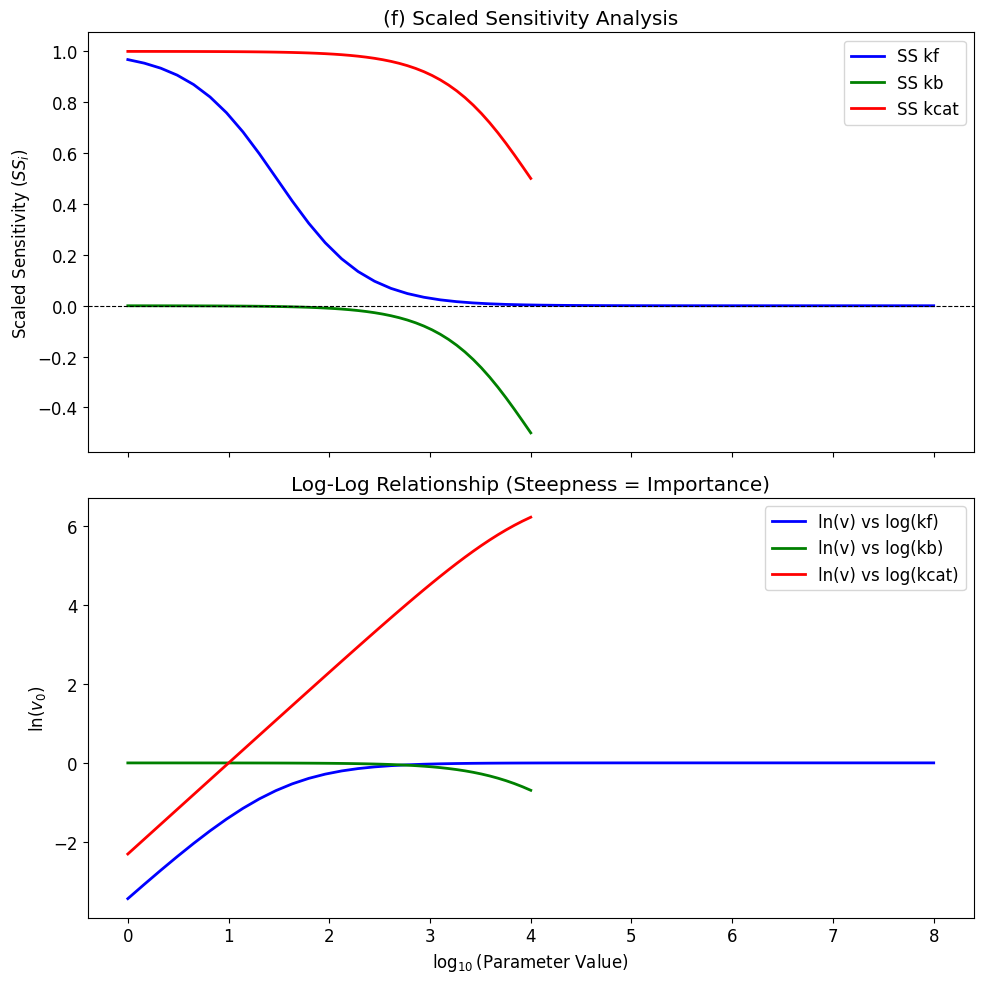


--- Numerical Slopes at Reference Point ---
Slope (Importance) of kf  :   0.0025
Slope (Importance) of kb  :  -0.0109
Slope (Importance) of kcat:   0.9892


In [7]:
# --- 1. Calculation Functions ---

def get_ln_v_data(param_name, param_range, ref_params):
    """Calculates ln(v0) for a range of a specific parameter."""
    kf_ref, kb_ref, kcat_ref, E0_ref = ref_params
    v_vals = []
    for p in param_range:
        # v0 must be your Michaelis-Menten function: vmax*S / (KM + S)
        if param_name == 'kf':    v = v0(p, kb_ref, kcat_ref, E0_ref)
        elif param_name == 'kb': v = v0(kf_ref, p, kcat_ref, E0_ref)
        elif param_name == 'kcat':v = v0(kf_ref, kb_ref, p, E0_ref)
        v_vals.append(np.log(v)) 
    return np.array(v_vals)

def scaled_sensitivity(param_name, param_range, ref_params):
    """Numerically computes scaled sensitivity (the slope) via central differences."""
    kf_ref, kb_ref, kcat_ref, E0_ref = ref_params
    sens = []
    for p in param_range:
        eps = p * 1e-5
        if param_name == 'kf':
            v_p, v_m, v_c = v0(p+eps, kb_ref, kcat_ref, E0_ref), v0(p-eps, kb_ref, kcat_ref, E0_ref), v0(p, kb_ref, kcat_ref, E0_ref)
        elif param_name == 'kb':
            v_p, v_m, v_c = v0(kf_ref, p+eps, kcat_ref, E0_ref), v0(kf_ref, p-eps, kcat_ref, E0_ref), v0(kf_ref, p, kcat_ref, E0_ref)
        elif param_name == 'kcat':
            v_p, v_m, v_c = v0(kf_ref, kb_ref, p+eps, E0_ref), v0(kf_ref, kb_ref, p-eps, E0_ref), v0(kf_ref, kb_ref, p, E0_ref)
        
        dv_dp = (v_p - v_m) / (2*eps)
        sens.append(p / v_c * dv_dp) # This is d(ln v) / d(ln p)
    return np.array(sens)

# --- 2. Plotting Two-Panel Analysis ---

ref = (kf_ref, kb_ref, kcat_ref, E0_ref)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for name, rng, color in [('kf', kf_range, 'b'), ('kb', kb_range, 'g'), ('kcat', kcat_range, 'r')]:
    log_p_axis = np.log10(rng)
    
    # Top Plot: Scaled Sensitivity (The Slope Value)
    ss_vals = scaled_sensitivity(name, rng, ref)
    ax1.plot(log_p_axis, ss_vals, label=f'SS {name}', color=color, lw=2)
    
    # Bottom Plot: Log-Log Relationship (The Curve whose slope we measure)
    ln_v_vals = get_ln_v_data(name, rng, ref)
    ax2.plot(log_p_axis, ln_v_vals, label=f'ln(v) vs log({name})', color=color, lw=2)

# Formatting
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax1.set_ylabel('Scaled Sensitivity ($SS_i$)')
ax1.set_title('(f) Scaled Sensitivity Analysis')
ax1.legend()

ax2.set_xlabel('$\log_{10}$(Parameter Value)')
ax2.set_ylabel('$\ln(v_0)$')
ax2.set_title('Log-Log Relationship (Steepness = Importance)')
ax2.legend()

plt.tight_layout()
plt.savefig('f_sensitivity_final.png', dpi=150)
plt.show()

# --- 3. Summary of Numerical Slopes ---
print('\n--- Numerical Slopes at Reference Point ---')
for name, rng in [('kf', kf_range), ('kb', kb_range), ('kcat', kcat_range)]:
    # Finding the slope at the middle of your range for comparison
    mid_idx = len(rng) // 2
    slope = scaled_sensitivity(name, rng, ref)[mid_idx]
    print(f"Slope (Importance) of {name:4}: {slope:8.4f}")

## Parts (g) & (h) – Competing reaction: enzyme produces P and P'

New mechanism:
$$S + E \underset{k_b}{\overset{k_f}{\rightleftharpoons}} ES \xrightarrow{k_{cat1}} P + E$$
$$ES \xrightarrow{k_{cat2}} P' + E$$

## Part (g) – Fundamental Molar Mass Balances

For a constant-volume batch reactor where $V$ is the volume, the fundamental mass balance for each species is defined by the rate of change of the number of moles ($n_i$). Based on the non-specific enzyme mechanism provided, the molar balances are:

### Substrate ($S$)
$$\frac{dn_S}{dt} = \left( -k_f \frac{n_E}{V} \frac{n_S}{V} + k_b \frac{n_{ES}}{V} \right) V$$

### Free Enzyme ($E$)
$$\frac{dn_E}{dt} = \left( -k_f \frac{n_E}{V} \frac{n_S}{V} + k_b \frac{n_{ES}}{V} + k_{cat1} \frac{n_{ES}}{V} + k_{cat2} \frac{n_{ES}}{V} \right) V$$

### Enzyme-Substrate Complex ($ES$)
$$\frac{dn_{ES}}{dt} = \left( k_f \frac{n_E}{V} \frac{n_S}{V} - (k_b + k_{cat1} + k_{cat2}) \frac{n_{ES}}{V} \right) V$$

### Product ($P$)
$$\frac{dn_P}{dt} = \left( k_{cat1} \frac{n_{ES}}{V} \right) V$$

### Product' ($P'$)
$$\frac{dn_{P'}}{dt} = \left( k_{cat2} \frac{n_{ES}}{V} \right) V$$

---

## Simplification to Concentration Balances

To simplify these to concentration balances, we assume the reactor volume $V$ is constant. Using the definition of concentration $[C_i] = \frac{n_i}{V}$, we substitute $n_i = [C_i]V$ into the molar balances. Since $V$ is constant, it is pulled out of the derivative and cancels on both sides, yielding the following system of ODEs:

* $$\frac{d[S]}{dt} = -k_f[E][S] + k_b[ES]$$
* $$\frac{d[E]}{dt} = -k_f[E][S] + (k_b + k_{cat1} + k_{cat2})[ES]$$
* $$\frac{d[ES]}{dt} = k_f[E][S] - (k_b + k_{cat1} + k_{cat2})[ES]$$
* $$\frac{d[P]}{dt} = k_{cat1}[ES]$$
* $$\frac{d[P']}{dt} = k_{cat2}[ES]$$

C:\Users\noah2\AppData\Local\Temp\ipykernel_9760\1346984962.py:34: RuntimeWarning: invalid value encountered in divide
  sel = np.where(total_prod > 1e-12, P_c / total_prod, np.nan)


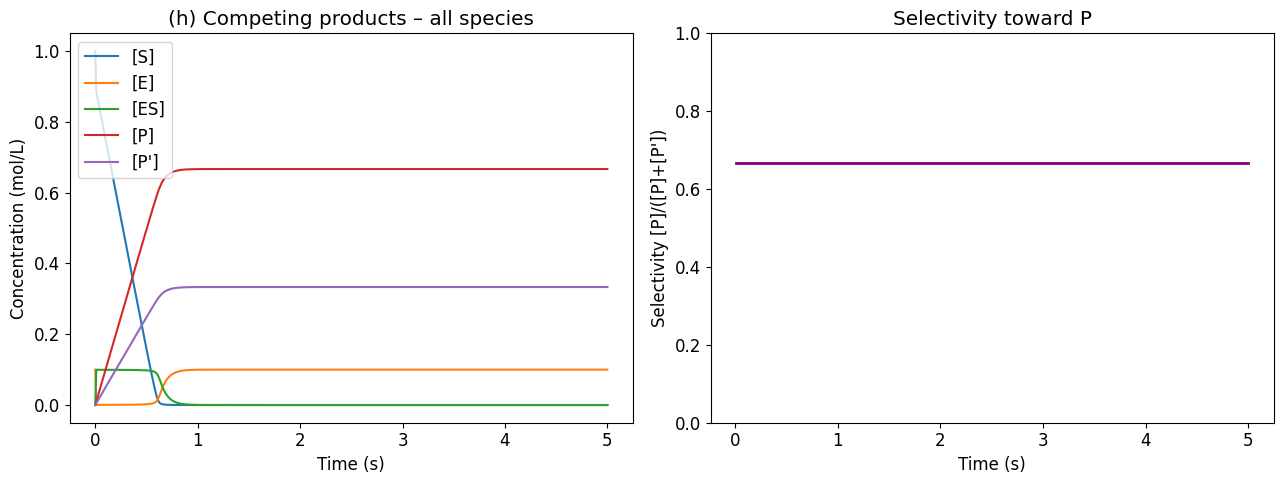

Steady-state selectivity = kcat1/(kcat1+kcat2) = 0.667


In [11]:
# ─── Parameters for competing reaction ───────────────────────────────────────
kcat1 = 10.0   # 1/s   → produces P
kcat2 = 5.0    # 1/s   → produces P'

def ode_competing(t, y, kf, km1, kcat1, kcat2):
    S, E, ES, P, Pp = y
    dS  = -kf*S*E + km1*ES
    dE  = -kf*S*E + km1*ES + (kcat1+kcat2)*ES
    dES =  kf*S*E - km1*ES - (kcat1+kcat2)*ES
    dP  =  kcat1 * ES
    dPp =  kcat2 * ES
    return [dS, dE, dES, dP, dPp]

y0_comp = [S0, E0, ES0, P0, 0.0]
sol_comp = solve_ivp(ode_competing, t_span, y0_comp,
                     args=(kf_ref, kb_ref, kcat1, kcat2),
                     t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-10)

S_c, E_c, ES_c, P_c, Pp_c = sol_comp.y

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sol_comp.t, S_c,  label='[S]')
axes[0].plot(sol_comp.t, E_c,  label='[E]')
axes[0].plot(sol_comp.t, ES_c, label='[ES]')
axes[0].plot(sol_comp.t, P_c,  label='[P]')
axes[0].plot(sol_comp.t, Pp_c, label="[P']")
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Concentration (mol/L)')
axes[0].set_title('(h) Competing products – all species')
axes[0].legend()

# Selectivity: P / (P + P')
total_prod = P_c + Pp_c
sel = np.where(total_prod > 1e-12, P_c / total_prod, np.nan)
axes[1].plot(sol_comp.t, sel, color='purple', lw=2)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Selectivity [P]/([P]+[P\'])')
axes[1].set_title('Selectivity toward P')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('h_competing.png', dpi=150)
plt.show()

sel_ss = kcat1 / (kcat1 + kcat2)
print(f'Steady-state selectivity = kcat1/(kcat1+kcat2) = {sel_ss:.3f}')

## Part (i) – Improving Selectivity

Both P and P' are formed from the **same intermediate ES**, so selectivity is:
$$\sigma_P = \frac{k_{cat1}}{k_{cat1} + k_{cat2}}$$

This is **independent of k₁, k₋₁, [S], and [E₀]**. The only way to improve selectivity is:

1. **Increase k_cat1** – engineer the enzyme to catalyse the desired reaction faster.
2. **Decrease k_cat2** – engineer the enzyme to suppress the side reaction.

Neither k₁ nor k₋₁ (nor [E₀]) affect selectivity because the ratio P:P' is set entirely by the branching at the ES node.

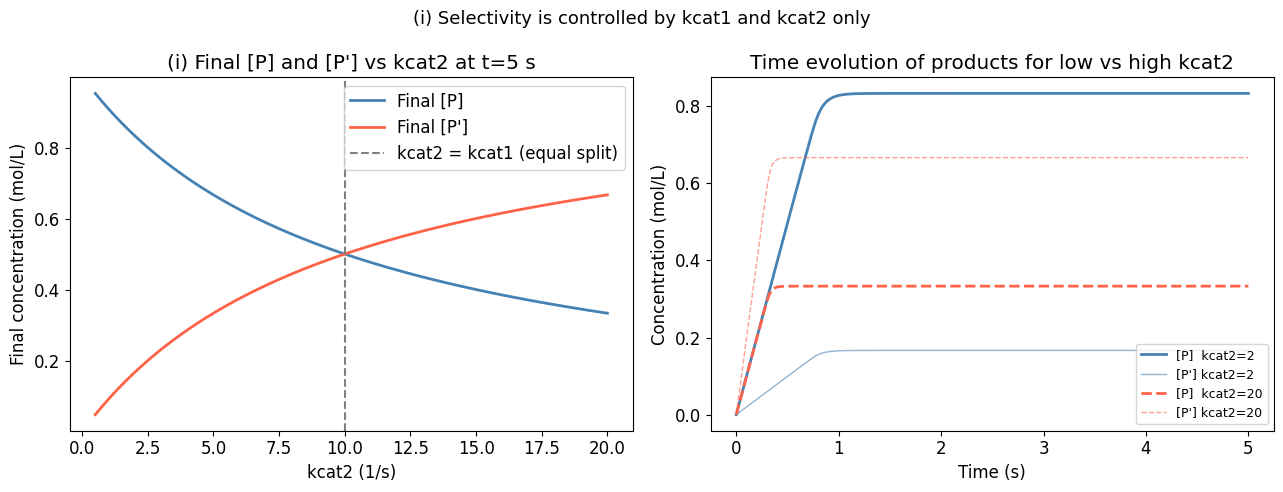

Key insight: σ_P = kcat1/(kcat1+kcat2) is a constant — it does not vary with
time, [S], k1, or km1. To improve selectivity toward P you must either
increase kcat1 or decrease kcat2 (i.e. engineer the enzyme active site).


In [12]:
# Note: selectivity σ = kcat1/(kcat1+kcat2) is a CONSTANT — independent of time,
# [S], k1, and km1. So a time-series selectivity plot just gives flat lines.
# Instead we show:
#   Left panel : final [P] and [P'] at t=5 s as a function of kcat2
#   Right panel: time evolution of [P] and [P'] for two extreme kcat2 cases

kcat2_sweep = np.linspace(0.5, 20, 80)
final_P, final_Pp = [], []

for kc2 in kcat2_sweep:
    sol_i = solve_ivp(ode_competing, t_span, y0_comp,
                      args=(kf, kb, kcat1, kc2),
                      t_eval=[5.0], method='Radau', rtol=1e-8, atol=1e-10)
    final_P.append(sol_i.y[3, -1])
    final_Pp.append(sol_i.y[4, -1])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: final yields vs kcat2
axes[0].plot(kcat2_sweep, final_P,  label='Final [P]',  color='steelblue', lw=2)
axes[0].plot(kcat2_sweep, final_Pp, label="Final [P']", color='tomato',    lw=2)
axes[0].axvline(kcat1, color='gray', ls='--', label='kcat2 = kcat1 (equal split)')
axes[0].set_xlabel('kcat2 (1/s)')
axes[0].set_ylabel('Final concentration (mol/L)')
axes[0].set_title('(i) Final [P] and [P\'] vs kcat2 at t=5 s')
axes[0].legend()

# Right: time evolution for kcat2=2 (selective) vs kcat2=20 (unselective)
colors = {'kcat2=2': 'steelblue', 'kcat2=20': 'tomato'}
for kc2, ls in [(2, '-'), (20, '--')]:
    sol_i = solve_ivp(ode_competing, t_span, y0_comp,
                      args=(kf, kb, kcat1, kc2),
                      t_eval=t_eval, method='BDF', rtol=1e-8, atol=1e-10)
    c = 'steelblue' if kc2 == 2 else 'tomato'
    axes[1].plot(sol_i.t, sol_i.y[3], color=c, ls=ls,       lw=2, label=f'[P]  kcat2={kc2}')
    axes[1].plot(sol_i.t, sol_i.y[4], color=c, ls=ls, lw=1, alpha=0.6, label=f"[P'] kcat2={kc2}")

axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Concentration (mol/L)')
axes[1].set_title('Time evolution of products for low vs high kcat2')
axes[1].legend(fontsize=9)

plt.suptitle('(i) Selectivity is controlled by kcat1 and kcat2 only', fontsize=13)
plt.tight_layout()
plt.savefig('i_selectivity.png', dpi=150)
plt.show()

print('Key insight: σ_P = kcat1/(kcat1+kcat2) is a constant — it does not vary with')
print('time, [S], k1, or km1. To improve selectivity toward P you must either')
print('increase kcat1 or decrease kcat2 (i.e. engineer the enzyme active site).')